In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
df = pd.read_csv('urban_air_quality_raw.csv', parse_dates=['date'])

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Date range:", df['date'].min(), "to", df['date'].max())
df.head()

Shape: (3000, 33)
Columns: ['record_id', 'city', 'state', 'zone_type', 'date', 'year', 'month', 'day_of_week', 'season', 'population', 'aqi', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'rainfall_mm', 'num_vehicles', 'num_industries', 'green_cover_pct', 'monitoring_stations', 'hospital_admissions', 'respiratory_cases', 'cardiovascular_cases', 'aqi_category', 'health_risk_score', 'data_source', 'data_quality_flag']
Date range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00


,record_id,city,state,zone_type,date,year,month,day_of_week,season,population,aqi,pm2_5,pm10,no2,so2,co,o3,nh3,temperature_c,humidity_pct,wind_speed_kmh,rainfall_mm,num_vehicles,num_industries,green_cover_pct,monitoring_stations,hospital_admissions,respiratory_cases,cardiovascular_cases,aqi_category,health_risk_score,data_source,data_quality_flag
0,1,Meerut,Uttar Pradesh,Industrial,2022-04-25,2022,4,Monday,Summer,1309023,190.90,70.06,151.71,92.88,79.10,1.94,74.85,2.46,29.00,64.60,19.00,3.60,380245,1724,5.30,8,85.00,49,23,NaN,NaN,Satellite,Manual Entry
1,2,Bangalore,Karnataka,IT Hub,2022-08-09,2022,8,Tuesday,Monsoon,8443675,102.10,59.93,64.77,15.15,9.19,9.59,98.48,40.55,26.70,35.40,17.80,2.50,2312274,14726,33.20,4,284.00,187,67,NaN,NaN,Satellite,Verified
2,3,Ranchi,Jharkhand,Industrial,2022-08-27,2022,8,Saturday,Monsoon,1073440,124.50,54.27,103.76,20.92,23.73,7.66,111.24,34.49,22.20,85.60,15.70,0.00,277574,971,18.00,4,44.00,26,8,NaN,NaN,CPCB,Manual Entry
3,4,Nagpur,Maharashtra,Commercial,2022-10-02,2022,10,Sunday,Post-Monsoon,2405665,145.50,46.53,125.87,86.87,70.61,4.30,84.90,44.35,25.20,51.30,18.30,6.10,653441,3898,44.90,7,143.00,82,29,NaN,NaN,CPCB,Verified
4,4,Nagpur,Maharashtra,Commercial,2022-10-02,2022,10,Sunday,Post-Monsoon,2405665,145.50,46.53,125.87,86.87,70.61,4.30,84.90,44.35,25.20,51.30,18.30,6.10,653441,3898,44.90,7,143.00,82,29,NaN,NaN,CPCB,Verified


In [10]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
record_id                  0
city                       0
state                      0
zone_type                  0
date                       0
year                       0
month                      0
day_of_week                0
season                     0
population                 0
aqi                      110
pm2_5                     79
pm10                       0
no2                        0
so2                        0
co                         0
o3                         0
nh3                        0
temperature_c             72
humidity_pct               0
wind_speed_kmh             0
rainfall_mm                0
num_vehicles               0
num_industries             0
green_cover_pct            0
monitoring_stations        0
hospital_admissions       49
respiratory_cases          0
cardiovascular_cases       0
aqi_category            3000
health_risk_score       3000
data_source                0
data_quality_flag          0
dtype: int64

=== Du

In [11]:
numeric_cols = [
    'aqi', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3',
    'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'rainfall_mm',
    'hospital_admissions', 'respiratory_cases', 'cardiovascular_cases'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types fixed successfully")
print(df[numeric_cols].dtypes)

Data types fixed successfully
aqi                     float64
pm2_5                   float64
pm10                    float64
no2                     float64
so2                     float64
co                      float64
o3                      float64
nh3                     float64
temperature_c           float64
humidity_pct            float64
wind_speed_kmh          float64
rainfall_mm             float64
hospital_admissions     float64
respiratory_cases         int64
cardiovascular_cases      int64
dtype: object


In [12]:
before = len(df)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Before : {before}")
print(f"After  : {len(df)}")
print(f"Removed: {before - len(df)} duplicate rows")

Before : 3000
After  : 2907
Removed: 93 duplicate rows


In [13]:
before = len(df)

df = df[df['aqi'] <= 500].copy()
df.reset_index(drop=True, inplace=True)

print(f"Before : {before}")
print(f"After  : {len(df)}")
print(f"Removed: {before - len(df)} invalid AQI rows")

Before : 2907
After  : 2732
Removed: 175 invalid AQI rows


In [14]:
print("Negative wind speed rows:", (df['wind_speed_kmh'] < 0).sum())

df['wind_speed_kmh'] = df['wind_speed_kmh'].abs()

print("Fixed! All wind speed values are now positive.")

Negative wind speed rows: 29
Fixed! All wind speed values are now positive.


In [15]:
cols_to_fill = ['aqi', 'pm2_5', 'temperature_c', 'hospital_admissions']

for col in cols_to_fill:
    missing = df[col].isnull().sum()
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col}: filled {missing} missing values with median {median_val:.2f}")

print("\nMissing values remaining:", df.isnull().sum().sum())

aqi: filled 0 missing values with median 134.80
pm2_5: filled 0 missing values with median 58.47
temperature_c: filled 38 missing values with median 28.25
hospital_admissions: filled 47 missing values with median 115.00

Missing values remaining: 5464


In [16]:
bins   = [0, 50, 100, 200, 300, 500]
labels = ['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

df['aqi_category'] = pd.cut(df['aqi'], bins=bins, labels=labels)

print(df['aqi_category'].value_counts())

aqi_category
Unhealthy         1358
Moderate           586
Very Unhealthy     510
Good               215
Hazardous           63
Name: count, dtype: int64


In [17]:
raw_score = (
    df['pm2_5'] * 0.40 +
    df['no2']   * 0.30 +
    df['so2']   * 0.20 +
    df['co']    * 0.10
)

min_val = raw_score.min()
max_val = raw_score.max()

df['health_risk_score'] = ((raw_score - min_val) / (max_val - min_val) * 100).round(2)

print("Health Risk Score added!")
print(df['health_risk_score'].describe())

Health Risk Score added!
count   2732.00
mean      37.55
std       16.68
min        0.00
25%       24.91
50%       35.64
75%       48.76
max      100.00
Name: health_risk_score, dtype: float64


In [18]:
print("=== Final Shape ===")
print(df.shape)

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values remaining")

print("\n=== Sample Data ===")
df[['city', 'aqi', 'aqi_category', 'health_risk_score']].head(10)

=== Final Shape ===
(2732, 33)

=== Missing Values ===
0 missing values remaining

=== Sample Data ===


,city,aqi,aqi_category,health_risk_score
0,Meerut,190.90,Unhealthy,48.81
1,Bangalore,102.10,Unhealthy,17.81
2,Ranchi,124.50,Unhealthy,19.48
3,Nagpur,145.50,Unhealthy,39.13
4,Amritsar,210.40,Very Unhealthy,57.28
5,Coimbatore,34.40,Good,7.05
6,Patna,156.20,Unhealthy,32.81
7,Hyderabad,260.40,Very Unhealthy,49.37
8,Delhi,103.40,Unhealthy,51.26
9,Jaipur,145.20,Unhealthy,45.76


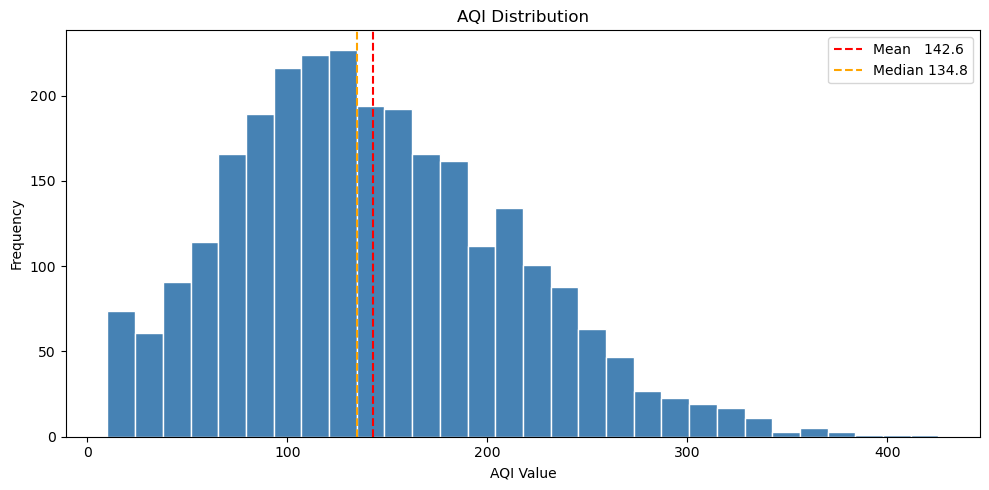

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(df['aqi'], bins=30, color='steelblue', edgecolor='white')

plt.axvline(df['aqi'].mean(),   color='red',    linestyle='--', label=f"Mean   {df['aqi'].mean():.1f}")
plt.axvline(df['aqi'].median(), color='orange', linestyle='--', label=f"Median {df['aqi'].median():.1f}")

plt.title('AQI Distribution')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('chart1_aqi_distribution.png', dpi=150)
plt.show()

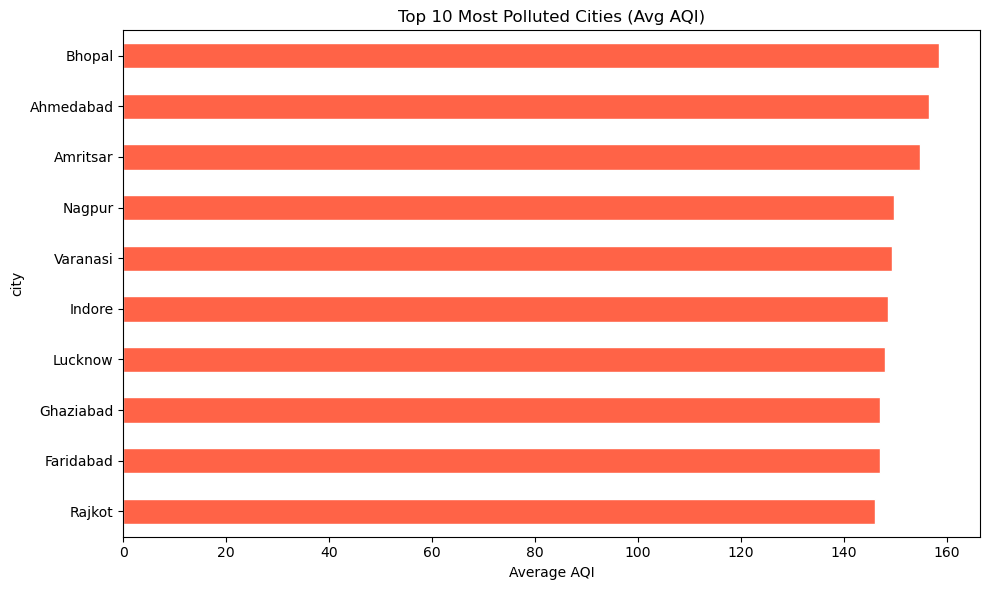

In [20]:
top_cities = df.groupby('city')['aqi'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_cities.plot(kind='barh', color='tomato', edgecolor='white')

plt.title('Top 10 Most Polluted Cities (Avg AQI)')
plt.xlabel('Average AQI')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_top_cities.png', dpi=150)
plt.show()

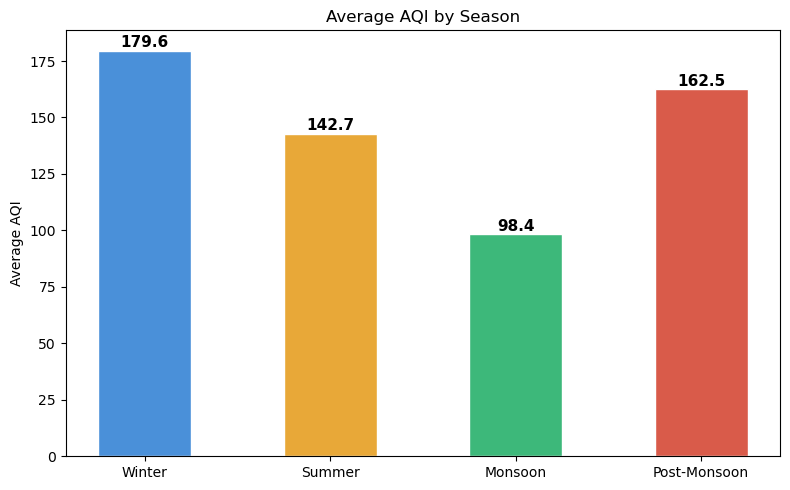

In [21]:
season_order  = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_colors = ['#4a90d9', '#e8a838', '#3db87a', '#d95b4a']

season_avg = df.groupby('season')['aqi'].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(season_avg.index, season_avg.values, color=season_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, season_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Average AQI by Season')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.savefig('chart3_seasonal_aqi.png', dpi=150)
plt.show()

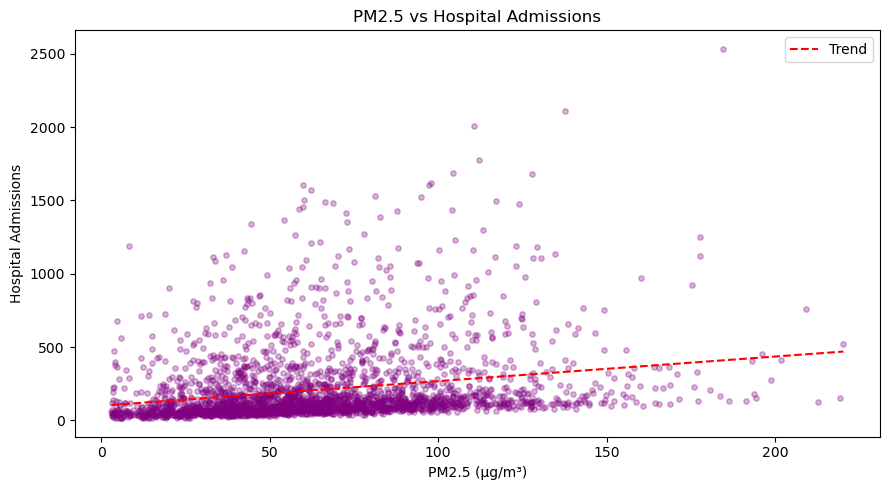

In [22]:
plt.figure(figsize=(9, 5))

plt.scatter(df['pm2_5'], df['hospital_admissions'],
            alpha=0.3, color='purple', s=15)

# Trend line
z = np.polyfit(df['pm2_5'], df['hospital_admissions'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['pm2_5'].min(), df['pm2_5'].max(), 200)
plt.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--', label='Trend')

plt.title('PM2.5 vs Hospital Admissions')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Hospital Admissions')
plt.legend()
plt.tight_layout()
plt.savefig('chart4_pm25_vs_hospital.png', dpi=150)
plt.show()

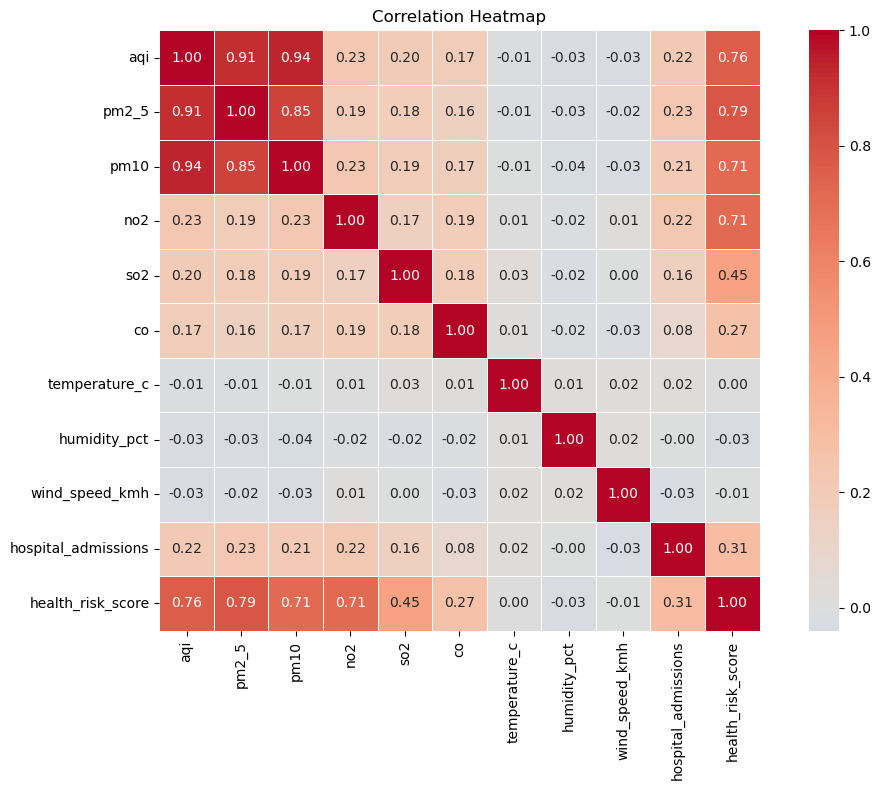

In [24]:
corr_cols = [
    'aqi', 'pm2_5', 'pm10', 'no2', 'so2', 'co',
    'temperature_c', 'humidity_pct', 'wind_speed_kmh',
    'hospital_admissions', 'health_risk_score'
]

plt.figure(figsize=(11, 8))

sns.heatmap(df[corr_cols].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart5_correlation.png', dpi=150)
plt.show()

In [25]:
df['hospital_admissions'] = df['hospital_admissions'].astype(int)
df.to_csv('air_quality_clean.csv', index=False)

In [26]:
df['hospital_admissions'] = df['hospital_admissions'].astype(int)
df.to_csv('air_quality_clean.csv', index=False)
print("Saved!")

Saved!
